In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END,add_messages
from typing import TypedDict,Annotated,List,Literal,Optional
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_core.prompts import ChatPromptTemplate
from langgraph.types import Send
import operator
from langchain_core.messages import BaseMessage
from pathlib import Path
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_community.tools.tavily_search import TavilySearchResults
import os

c:\Users\abc\anaconda3\Lib\site-packages\torch\cuda\__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
load_dotenv()

HF_KEY = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

model_openai = ChatOpenAI(model = "gpt-4.1-mini")

llm=HuggingFaceEndpoint(
    repo_id='Qwen/Qwen2.5-7B-Instruct',
    task='text-generation',
)

model_hf=ChatHuggingFace(llm=llm)

In [3]:
class Task(BaseModel):

    id : int
    title : str = Field(description = 'Title of the task')
    goal : str = Field(...,description="One sentence describing what the reader should be able to do/understand after this section.")
    bullets : List[str] = Field(...,min_length=3,max_length=5,description = "3–5 concrete, non-overlapping subpoints to cover in this section.")
    target_words : int = Field(...,description="Target word count for this section (120–450).")
    section_type : Literal["intro", "core", "examples", "checklist", "common_mistakes", "conclusion"] = Field(...,description="Use 'common_mistakes' exactly once in the plan.")

In [4]:
class Plan(BaseModel):

    blog_title : str = Field(description = 'Title of the blog')
    audience : str = Field(...,description = "Who this blog is for.")
    tone : str = Field(...,description ="Writing tone (e.g., practical, crisp).")
    blog_kind : Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraint : List[str] = Field(default_factory = list)
    task : List[Task]

In [5]:
class EvidenceItem(BaseModel):
    title : str
    url : str
    published_at : Optional[str]
    snippet : Optional[str]
    source : Optional[str]

In [6]:
class BlogState(TypedDict):

    topic : str
    mode : str
    needs_research : bool = Field(...,description = 'True or False')
    queries : List[str]
    evidence : List[EvidenceItem]

    plan : Optional[Plan]
    section : Annotated[List[tuple[int,str]],operator.add]
    final : str

    merged_md : str
    md_with_placeholder : str
    image_specs : List[str]

In [7]:
def orchestrator(state:BlogState)->dict:
    
    topic = state['topic']

    model_with_structure = model_openai.with_structured_output(Plan)

    template = ChatPromptTemplate([
        ('system',"You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."),
        ('human',"topic : {topic}")
    ])

    chain = template | model_with_structure

    response = chain.invoke({'topic':topic})

    print("Control at orchestrator ")

    return {'plan':response}

In [8]:
def fanout(state: BlogState):

    print("Control at Fanout")

    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state["plan"].task
    ]

In [9]:
# Worker

def worker(payload : dict)->dict:

    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']
    evidence = payload.get('evidence', [])

    blog_title = plan['blog_title']
    section_type = task['section_type']
    audience = plan['audience']
    tone = plan['tone']
    task_title = task['title']
    goal = task['goal']
    bullet_text = '\n- ' + '\n-'.join(task['bullets'])
    target_words = task['target_words']

    evidence_text = ""
    for e in evidence:
        evidence_text = "\n".join(
            f"- {e['title']} | {e['url']} | {e['published_at'] or 'date:unknown'}".strip()
            for e in evidence[:20]
        )


    template = ChatPromptTemplate([
        ('system',"You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"),
        ('human',f"Blog: {blog_title}\n"
                    f"Audience: {audience}\n"
                    f"Tone: {tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task_title}\n"
                    f"Section type: {section_type}\n"
                    f"Goal: {goal}\n"
                    f"Target words: {target_words}\n"
                    f"Bullets:{bullet_text}\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n")
    ])

    chain = template | model_openai

    response = chain.invoke({'blog_title':blog_title,'audience':audience,'tone':tone,'topic':topic,'task_title':task_title,'section_type':section_type,'goal':goal,'target_words':target_words,'bullet_text':bullet_text})

    print("Control at Worker node")

    return {'section':[(task['id'],response.content)]}

In [10]:
# Sub_Graph_Reducer ->  merge_content

def merge_content(state: BlogState) -> dict:

    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["section"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f"# {plan.blog_title}\n\n{body}\n"

    print("Control at merge_content")

    return {"merged_md": merged_md}
    

In [11]:
# Sub_Graph_Reducer ->  def decide_image():


class ImageSpec(BaseModel):

    placeholder : str = Field(...,description = "e.g. [[IMAGE_1]]")
    filename : str = Field(..., description = "Save under images/, e.g. qkv_flow.png")
    alt : str
    caption : str 
    prompt : str = Field(..., description = "Prompt to send to the image model.")
    size : Literal["1024x1024", "1024x1536", "1536x1024"] = "1024x1024"
    quality : Literal['low','medium','high']

class GlobalImagePlan(BaseModel):

    md_with_placeholder : str
    images : List[ImageSpec] = Field(default_factory = list)

template_decide_image = ChatPromptTemplate([
    ('system',"""
        You are an expert technical editor.
        Decide if images/diagrams are needed for THIS blog.

        Rules:
        - Max 3 images total.
        - Each image must materially improve understanding (diagram/flow/table-like visual).
        - Insert placeholders exactly: [[IMAGE_1]], [[IMAGE_2]], [[IMAGE_3]].
        - If no images needed: md_with_placeholders must equal input and images=[].
        - Avoid decorative images; prefer technical diagrams with short labels.
        Return strictly GlobalImagePlan.
        """),
    ('human',"Blog Kind : {blog_kind}\n"
                "Topic : {topic} \n"
                "Insert placeholders + propose image prompts.\n\n {merged_md}"
                )
],
input_variables = ['blog_kind','topic','merged_md']
)

model_decide_image = model_openai.with_structured_output(GlobalImagePlan)

chain_decide_image = template_decide_image | model_decide_image

def decide_image(state : BlogState)->dict:

    topic = state['topic']

    plan = state['plan']
    blog_kind = plan.blog_kind

    merged_md = state['merged_md']


    image_plan : GlobalImagePlan = chain_decide_image.invoke({'topic':topic,'blog_kind':blog_kind,'merged_md':merged_md})

    print("Control at Sub_Graph_Reducer ->  def decide_image()")

    raw_output = chain_decide_image.run({'topic':topic,'blog_kind':blog_kind,'merged_md':merged_md})
    print("Raw Model Output:", raw_output)

    return {'md_with_placeholder':image_plan.md_with_placeholder,'image_specs' : [image.model_dump() for image in image_plan.images] }

In [12]:
# # Sub_Graph_Reducer -> private function

# def _gemini_generate_image_bytes(prompt: str) -> bytes:
#     """
#     Returns raw image bytes generated by Gemini.
#     Requires: pip install google-genai
#     Env var: GOOGLE_API_KEY
#     """
#     from google import genai
#     from google.genai import types

#     api_key = os.environ.get("GOOGLE_API_KEY")
#     if not api_key:
#         raise RuntimeError("GOOGLE_API_KEY is not set.")

#     client = genai.Client(api_key=api_key)

#     resp = client.models.generate_content(
#         model="gemini-2.5-flash-image",
#         contents=prompt,
#         config=types.GenerateContentConfig(
#             response_modalities=["IMAGE"],
#             safety_settings=[
#                 types.SafetySetting(
#                     category="HARM_CATEGORY_DANGEROUS_CONTENT",
#                     threshold="BLOCK_ONLY_HIGH",
#                 )
#             ],
#         ),
#     )

#     # Depending on SDK version, parts may hang off resp.candidates[0].content.parts
#     parts = getattr(resp, "parts", None)
#     if not parts and getattr(resp, "candidates", None):
#         try:
#             parts = resp.candidates[0].content.parts
#         except Exception:
#             parts = None

#     if not parts:
#         raise RuntimeError("No image content returned (safety/quota/SDK change).")

#     for part in parts:
#         inline = getattr(part, "inline_data", None)
#         if inline and getattr(inline, "data", None):
#             return inline.data
        
#     print("Control at Sub_Graph_Reducer -> private function")

#     raise RuntimeError("No inline image bytes found in response.")

In [13]:
# Sub_Graph_Reducer -> private function

import openai
import base64
from pathlib import Path

def _gemini_generate_image_bytes(prompt: str, size="1024x1024") -> bytes:
    """Generate image bytes using OpenAI's DALL·E model."""
    resp = openai.images.generate(
        model="gpt-image-1",
        prompt=prompt,
        size=size
    )
    img_b64 = resp.data[0].b64_json
    return base64.b64decode(img_b64)

In [14]:
# def generate_place_image(state: BlogState) -> dict:

#     plan = state["plan"]
#     assert plan is not None

#     md = state.get("md_with_placeholders") or state["merged_md"]
#     image_specs = state.get("image_specs", []) or []

#     # If no images requested, just write merged markdown
#     if not image_specs:
#         filename = f"{plan.blog_title}.md"
#         Path(filename).write_text(md, encoding="utf-8")
#         return {"final": md}

#     images_dir = Path("images")
#     images_dir.mkdir(exist_ok=True)

#     for spec in image_specs:
#         placeholder = spec["placeholder"]
#         filename = spec["filename"]
#         out_path = images_dir / filename

#         # generate only if needed
#         if not out_path.exists():
#             try:
#                 img_bytes = _gemini_generate_image_bytes(spec["prompt"])
#                 out_path.write_bytes(img_bytes)
#             except Exception as e:
#                 # graceful fallback: keep doc usable
#                 prompt_block = (
#                     f"> **[IMAGE GENERATION FAILED]** {spec.get('caption','')}\n>\n"
#                     f"> **Alt:** {spec.get('alt','')}\n>\n"
#                     f"> **Prompt:** {spec.get('prompt','')}\n>\n"
#                     f"> **Error:** {e}\n"
#                 )
#                 md = md.replace(placeholder, prompt_block)
#                 continue

#         img_md = f"![{spec['alt']}](images/{filename})\n*{spec['caption']}*"
#         md = md.replace(placeholder, img_md)

#     #filename = f"{plan.blog_title}.md"
#     filename = "Mastering UKG Pro Workforce Management.md"
#     Path(filename).write_text(md, encoding="utf-8")

#     print("Control at Sub_graph generate_place_image ")

#     return {"final": md}

In [15]:
def generate_place_image(state: BlogState) -> dict:

    plan = state["plan"]
    assert plan is not None

    md = state.get("md_with_placeholders") or state["merged_md"]
    image_specs = state.get("image_specs", []) or []

    # If no images requested, just write merged markdown
    if not image_specs:
        filename = f"{plan.blog_title}.md"
        Path(filename).write_text(md, encoding="utf-8")
        return {"final": md}

    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)

    for spec in image_specs:
        placeholder = spec["placeholder"]
        filename = spec["filename"]
        out_path = images_dir / filename

        # generate only if needed
        if not out_path.exists():
            try:
                img_bytes = _gemini_generate_image_bytes(
                    spec["prompt"], size=spec.get("size", "1024x1024")
                )
                out_path.write_bytes(img_bytes)
            except Exception as e:
                # graceful fallback: keep doc usable
                prompt_block = (
                    f"> **[IMAGE GENERATION FAILED]** {spec.get('caption','')}\n>\n"
                    f"> **Alt:** {spec.get('alt','')}\n>\n"
                    f"> **Prompt:** {spec.get('prompt','')}\n>\n"
                    f"> **Error:** {e}\n"
                )
                md = md.replace(placeholder, prompt_block)
                continue

        # Replace placeholder with markdown
        #img_md = f"![{spec['alt']}](images/{filename})\n*{spec['caption']}*"
        img_md = f"![{spec['alt']}](./images/{filename})\n*{spec['caption']}*"
        #md = md.replace(placeholder, img_md)

        if placeholder in md:
            md = md.replace(placeholder, img_md)
        else:
            print(f"WARNING: placeholder {placeholder} not found in Markdown")

    #filename = f"{plan.blog_title}.md"
    filename = f"Transformer_Architecture.md"
    Path(filename).write_text(md, encoding="utf-8")

    print("Control at Sub_graph generate_place_image with OpenAI DALL·E")

    return {"final": md}

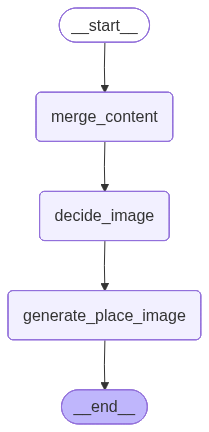

In [16]:
sub_graph = StateGraph(BlogState)

sub_graph.add_node('merge_content',merge_content)
sub_graph.add_node('decide_image',decide_image)
sub_graph.add_node('generate_place_image',generate_place_image)

sub_graph.add_edge(START,'merge_content')
sub_graph.add_edge('merge_content','decide_image')
sub_graph.add_edge('decide_image','generate_place_image')
sub_graph.add_edge('generate_place_image',END)

reduce_sub_graph = sub_graph.compile()

reduce_sub_graph

In [17]:
# router

class RouterDecision(BaseModel):

    need_research : bool = Field(...,description = "True or False")
    mode : Literal["closed_book", "hybrid", "open_book"]
    queries : List[str] = Field(default_factory = list)

template = ChatPromptTemplate.from_messages([
    ('system',"""You are a routing module for a technical blog planner.

    Decide whether web research is needed BEFORE planning.

    Modes:
    - closed_book (needs_research=false):
    Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
    - hybrid (needs_research=true):
    Mostly evergreen but needs up-to-date examples/tools/models to be useful.
    - open_book (needs_research=true):
    Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

    If needs_research=true:
    - Output 3–10 high-signal queries.
    - Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
    - If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
    """),
    ('human',"Topic : {topic}")
])

print(template.input_variables)

model_with_structure = model_openai.with_structured_output(RouterDecision)

router_chain = template | model_with_structure

def router(state:BlogState)->dict:

    topic = state['topic']

    prompt = {'topic':topic}

    decision : RouterDecision = router_chain.invoke(prompt)

    print("Control at Router")

    return {
        'needs_research' : decision.need_research,
        'mode' : decision.mode,
        'queries' : decision.queries
    }

['topic']


In [18]:
def route_reflector(state : BlogState)->dict:

    needs_research = state['needs_research']

    print("control at route_reflector")

    if needs_research:
        return 'research'
    else:
        return 'orchestrator'

In [19]:
# research

class EvidencePack(BaseModel):

    evidence : List[EvidenceItem] = Field(default_factory = list)

template = ChatPromptTemplate([
    ('system',"""You are a research synthesizer for technical writing.

        Given raw web search results, produce a deduplicated list of EvidenceItem objects.

        Rules:
        - Only include items with a non-empty url.
        - Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
        - If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
        If missing or unclear, set published_at=null. Do NOT guess.
        - Keep snippets short.
        - Deduplicate by URL.
        """),
    ('human',"Raw result : {raw_result}")
],
input_variables = ['raw_result']
)

model_with_structure = model_openai.with_structured_output(EvidencePack)

research_chain = template | model_with_structure

# tavily function

def _tavily_search(query : str,max_results : int = 5):

    tool = TavilySearchResults(max_results = max_results)
    response = tool.invoke({'query' : query})

    normalized : List[dict] = []

    for res in response:
        normalized.append(
            {
                "title": res.get("title") or "",
                "url": res.get("url") or "",
                "snippet": res.get("content") or res.get("snippet") or "",
                "published_at": res.get("published_date") or res.get("published_at"),
                "source": res.get("source")
            }
        )
    
    return normalized


def research(state:BlogState)->dict:

    queries = state['queries']
    max_results = 6

    raw_result : List[dict] = []

    for query in queries:
        raw_result.extend(_tavily_search(query,max_results = max_results)) 

    if not raw_result:
        return {'evidence':[]}
    
    pack : EvidencePack = research_chain.invoke({'raw_result':raw_result})

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    print("Control at research")

    return {"evidence": list(dedup.values())}

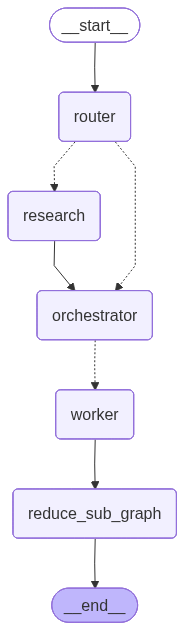

In [20]:
graph = StateGraph(BlogState)

graph.add_node('router',router)
graph.add_node('research',research)
graph.add_node('orchestrator',orchestrator)
graph.add_node('worker',worker)
graph.add_node('reduce_sub_graph',reduce_sub_graph)

graph.add_edge(START,'router')
graph.add_conditional_edges('router',route_reflector,{'research':'research','orchestrator':'orchestrator'})
graph.add_edge('research','orchestrator')
graph.add_conditional_edges('orchestrator',fanout,['worker'])
graph.add_edge('worker','reduce_sub_graph')
graph.add_edge('reduce_sub_graph',END)

blog = graph.compile()

blog

In [21]:
response = blog.invoke({'topic':'Transformer Architecture'})

print(response)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}